# 4. Counterfactual Fairness (Kusner et al., 2017)

**Author:** Matteo

## What this notebook does

We implement the **individual-level counterfactual fairness** test from
Kusner et al. (2017): for each employee, we flip a protected attribute and
re-run the model. If the prediction changes, the model's decision depended
on that attribute — a violation of counterfactual fairness.

**Question:** *"If this employee's protected attribute were different,
would the model predict the same outcome?"*

## Connection to the rest of the project

- **Notebook 04** (Level 1) asked: does the model predict equal *rates* of
  attrition across groups? (group-level, statistical parity)
- **This notebook** (Level 2) asks: does the model treat *individual*
  employees differently based on their protected attributes?
- **Notebook 06** (Level 3 — FACTS) asks: even if prediction looks fair,
  is the *recourse* equally achievable?

These three levels are complementary — a model can pass Level 1 and still
fail Level 2, and pass both while failing Level 3.

## Scope and limitations

We test **Gender** (binary: Male/Female) and **Age** (continuous, pushed
across the AGE_THRESHOLD). We exclude **MaritalStatus** from the flip test
because it has three categories (Single/Married/Divorced) — flipping it
requires choosing a target category, which introduces an arbitrary choice
that would make the flip rate depend on the chosen direction rather than on
the model's fairness. Gender and Age are the most policy-relevant attributes
in HR contexts and have a natural flip operation.

Note (Kusner 2017): a fully causal treatment requires a structural causal
model. Our flip test is the standard practical approximation used when no
causal graph is available. The flip rate is a lower bound on causal unfairness.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    ScaledModelWrapper, load_artifacts, load_raw_with_split,
    get_project_paths, AGE_THRESHOLD, PROTECTED_ATTRIBUTES,
)

PATHS     = get_project_paths()
THRESHOLD = 0.20

print('Paths:')
for k, v in PATHS.items():
    print(f'  {k}: {v}')


Paths:
  BASE: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project
  DATA: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
  RF: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF
  XGBoost: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost
  FAIRNESS: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness


In [2]:
df_raw, df_encoded, feature_cols = load_raw_with_split()
rf  = load_artifacts(PATHS['RF'])
xgb = load_artifacts(PATHS['XGBoost'])
feature_names = rf['feature_names']

rf_wrapper  = ScaledModelWrapper(rf['model'],  rf['scaler'],  feature_names)
xgb_wrapper = ScaledModelWrapper(xgb['model'], xgb['scaler'], feature_names)
print(f'Dataset: {len(df_raw)} employees | Features: {len(feature_names)}')
print('Models loaded.')


Dataset: 1470 employees | Features: 30
Models loaded.


## Flip test — full population

We run the flip test on **all 1470 employees**, not just the at-risk ones.
This answers the broader question: does the model treat any employee
differently based on their protected attribute, regardless of whether they
are currently predicted as at-risk?

`Gender` is label-encoded as 0/1 — we swap it to the opposite value.
For `Age` we push each employee 15 years across the `AGE_THRESHOLD` (35),
clipped to the realistic 18-60 range. Everything else stays constant.


In [3]:
def cf_fairness_flip(wrapper, df_encoded, feature_names, attr,
                     flip_fn, threshold=THRESHOLD):
    """
    flip_fn(X_df) -> X_df_modified : returns a copy with `attr` perturbed.
    Returns flip_rate and a boolean mask of which employees flipped.
    """
    X = df_encoded[feature_names].astype("float64").copy()
    base_pred = (wrapper.predict_proba(X)[:, 1] >= threshold).astype(int)

    X_flip = flip_fn(X.copy())
    flip_pred = (wrapper.predict_proba(X_flip)[:, 1] >= threshold).astype(int)

    flipped = base_pred != flip_pred
    return flipped.mean(), flipped


def flip_gender(X):
    # Gender encoded 0/1 -> swap to the other class
    X["Gender"] = 1 - X["Gender"]
    return X


def shift_age(X, offset=15):
    # Push everyone across the age band (clipped to a realistic 18-60 range)
    X["Age"] = np.clip(X["Age"] + np.where(X["Age"] < AGE_THRESHOLD, offset, -offset),
                       18, 60)
    return X

In [4]:
results = []
for model_name, wrapper in [('Random Forest', rf_wrapper), ('XGBoost', xgb_wrapper)]:
    g_rate, g_mask = cf_fairness_flip(wrapper, df_encoded, feature_names, 'Gender', flip_gender)
    a_rate, a_mask = cf_fairness_flip(wrapper, df_encoded, feature_names, 'Age', shift_age)
    results.append({
        'model':            model_name,
        'gender_flip_rate': round(g_rate, 3),
        'age_flip_rate':    round(a_rate, 3),
    })
    print(f'{model_name}:')
    print(f'  Flipping Gender changes {g_rate:.1%} of predictions ({int(g_rate*len(df_raw))} employees)')
    print(f'  Shifting Age   changes {a_rate:.1%} of predictions ({int(a_rate*len(df_raw))} employees)')
    print()

cf_fairness_df = pd.DataFrame(results)
cf_fairness_df.to_csv(os.path.join(PATHS['FAIRNESS'], 'level2_cf_fairness_full.csv'), index=False)


Random Forest:
  Flipping Gender changes 1.9% of predictions (28 employees)
  Shifting Age   changes 13.4% of predictions (196 employees)

XGBoost:
  Flipping Gender changes 2.0% of predictions (28 employees)
  Shifting Age   changes 6.8% of predictions (100 employees)



## Flip test — at-risk employees only

We now restrict the analysis to employees the model flags as at-risk
(proba >= 0.20). This connects directly to notebook 04: among the people
already predicted to leave, does flipping a protected attribute save them
(flip to not-at-risk) more often for one group than another?

A high flip rate **among at-risk employees** is particularly concerning —
it means the model is using the protected attribute to decide *who* gets
flagged, not just as a correlate of other features.


In [5]:
# Load recourse dataset from notebook 04 to get the at-risk indices
recourse_rf  = pd.read_csv(os.path.join(PATHS['FAIRNESS'], 'recourse_RF.csv'))
recourse_xgb = pd.read_csv(os.path.join(PATHS['FAIRNESS'], 'recourse_XGB.csv'))

at_risk_results = []
for model_name, wrapper, recourse_df in [
    ('Random Forest', rf_wrapper,  recourse_rf),
    ('XGBoost',       xgb_wrapper, recourse_xgb),
]:
    at_risk_idx = recourse_df['emp_id'].values
    df_enc_risk = df_encoded.iloc[at_risk_idx].reset_index(drop=True)

    g_rate, g_mask = cf_fairness_flip(wrapper, df_enc_risk, feature_names, 'Gender', flip_gender)
    a_rate, a_mask = cf_fairness_flip(wrapper, df_enc_risk, feature_names, 'Age', shift_age)

    at_risk_results.append({
        'model':            model_name,
        'n_at_risk':        len(at_risk_idx),
        'gender_flip_rate': round(g_rate, 3),
        'age_flip_rate':    round(a_rate, 3),
    })
    print(f'{model_name} (at-risk only, n={len(at_risk_idx)}):')
    print(f'  Flipping Gender saves {g_rate:.1%} ({int(g_rate*len(at_risk_idx))} employees)')
    print(f'  Shifting Age   saves {a_rate:.1%} ({int(a_rate*len(at_risk_idx))} employees)')
    print()

at_risk_df = pd.DataFrame(at_risk_results)
at_risk_df.to_csv(os.path.join(PATHS['FAIRNESS'], 'level2_cf_fairness_atrisk.csv'), index=False)


Random Forest (at-risk only, n=249):
  Flipping Gender saves 0.0% (0 employees)
  Shifting Age   saves 0.0% (0 employees)

XGBoost (at-risk only, n=325):
  Flipping Gender saves 0.0% (0 employees)
  Shifting Age   saves 0.0% (0 employees)



## Visualisation — full population vs at-risk


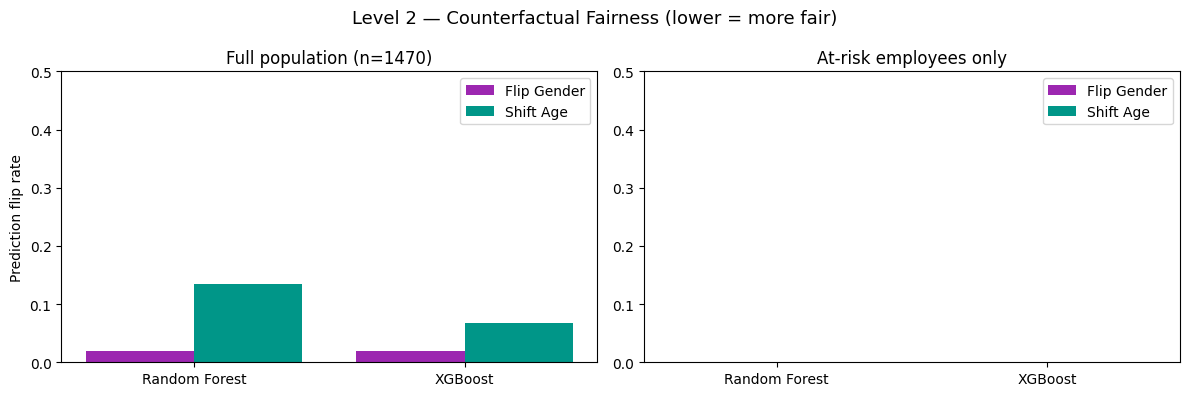

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full population
ax = axes[0]
x  = np.arange(len(cf_fairness_df))
ax.bar(x - 0.2, cf_fairness_df['gender_flip_rate'], 0.4, label='Flip Gender', color='#9C27B0')
ax.bar(x + 0.2, cf_fairness_df['age_flip_rate'],    0.4, label='Shift Age',   color='#009688')
ax.set_xticks(x); ax.set_xticklabels(cf_fairness_df['model'])
ax.set_ylabel('Prediction flip rate')
ax.set_title('Full population (n=1470)')
ax.set_ylim(0, 0.5)
ax.legend()

# Right: at-risk only
ax2 = axes[1]
x2  = np.arange(len(at_risk_df))
ax2.bar(x2 - 0.2, at_risk_df['gender_flip_rate'], 0.4, label='Flip Gender', color='#9C27B0')
ax2.bar(x2 + 0.2, at_risk_df['age_flip_rate'],    0.4, label='Shift Age',   color='#009688')
ax2.set_xticks(x2); ax2.set_xticklabels(at_risk_df['model'])
ax2.set_title('At-risk employees only')
ax2.set_ylim(0, 0.5)
ax2.legend()

fig.suptitle('Level 2 — Counterfactual Fairness (lower = more fair)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['FAIRNESS'], 'level2_counterfactual_fairness.png'), dpi=120)
plt.show()


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTICA — validazione risultati notebook 05
# ─────────────────────────────────────────────────────────────────────────────
SEP = "=" * 65

# ── 1. FULL POPULATION ────────────────────────────────────────────────────────
print(SEP)
print("1. FLIP TEST — FULL POPULATION (n=1470)")
print(SEP)
print(cf_fairness_df.to_string(index=False))
print()
for _, row in cf_fairness_df.iterrows():
    g = row['gender_flip_rate']
    a = row['age_flip_rate']
    print(f"  {row['model']}:")
    print(f"    Gender: {g:.1%} ({int(g*len(df_raw))} dipendenti cambiano outcome)")
    print(f"    Age:    {a:.1%} ({int(a*len(df_raw))} dipendenti cambiano outcome)")
    print(f"    {'⚠️  modello usa Gender' if g > 0.05 else '✅ Gender ok'}  |  {'⚠️  modello usa Age' if a > 0.05 else '✅ Age ok'}")
    print()

# ── 2. AT-RISK ONLY ───────────────────────────────────────────────────────────
print(SEP)
print("2. FLIP TEST — AT-RISK ONLY")
print(SEP)
print(at_risk_df.to_string(index=False))
print()
for _, row in at_risk_df.iterrows():
    g = row['gender_flip_rate']
    a = row['age_flip_rate']
    n = row['n_at_risk']
    print(f"  {row['model']} (n={n}):")
    print(f"    Gender: {g:.1%} ({int(g*n)} at-risk sarebbero salvati)")
    print(f"    Age:    {a:.1%} ({int(a*n)} at-risk sarebbero salvati)")
    print(f"    {'⚠️  dipendenza da Gender' if g > 0.05 else '✅ Gender ok'}  |  {'⚠️  dipendenza da Age' if a > 0.05 else '✅ Age ok'}")
    print()

# ── 3. CONFRONTO FULL VS AT-RISK ──────────────────────────────────────────────
print(SEP)
print("3. CONFRONTO: full population vs at-risk")
print(SEP)
print("  Se at-risk > full: il modello usa l'attributo più pesantemente")
print("  per decidere chi flaggare, non solo come correlato generale.")
print()
for model_name in ['Random Forest', 'XGBoost']:
    full = cf_fairness_df[cf_fairness_df['model'] == model_name].iloc[0]
    risk = at_risk_df[at_risk_df['model'] == model_name].iloc[0]
    print(f"  {model_name}:")
    for attr in ['gender', 'age']:
        f_rate = full[f'{attr}_flip_rate']
        r_rate = risk[f'{attr}_flip_rate']
        diff   = round(r_rate - f_rate, 3)
        direction = '↑ più forte tra at-risk' if diff > 0.02 else ('↓ meno forte tra at-risk' if diff < -0.02 else '≈ simile')
        print(f"    {attr:8s}: full={f_rate:.1%}  at-risk={r_rate:.1%}  diff={diff:+.3f}  {direction}")
    print()

# ── 4. FILE SALVATI ───────────────────────────────────────────────────────────
print(SEP)
print("4. FILE SALVATI")
print(SEP)
for fname in sorted(os.listdir(PATHS['FAIRNESS'])):
    if 'level2' in fname:
        fpath = os.path.join(PATHS['FAIRNESS'], fname)
        print(f"  ✅ {fname}  ({os.path.getsize(fpath):,} bytes)")

1. FLIP TEST — FULL POPULATION (n=1470)
        model  gender_flip_rate  age_flip_rate
Random Forest             0.019          0.134
      XGBoost             0.020          0.068

  Random Forest:
    Gender: 1.9% (27 dipendenti cambiano outcome)
    Age:    13.4% (196 dipendenti cambiano outcome)
    ✅ Gender ok  |  ⚠️  modello usa Age

  XGBoost:
    Gender: 2.0% (29 dipendenti cambiano outcome)
    Age:    6.8% (99 dipendenti cambiano outcome)
    ✅ Gender ok  |  ⚠️  modello usa Age

2. FLIP TEST — AT-RISK ONLY
        model  n_at_risk  gender_flip_rate  age_flip_rate
Random Forest        249               0.0            0.0
      XGBoost        325               0.0            0.0

  Random Forest (n=249):
    Gender: 0.0% (0 at-risk sarebbero salvati)
    Age:    0.0% (0 at-risk sarebbero salvati)
    ✅ Gender ok  |  ✅ Age ok

  XGBoost (n=325):
    Gender: 0.0% (0 at-risk sarebbero salvati)
    Age:    0.0% (0 at-risk sarebbero salvati)
    ✅ Gender ok  |  ✅ Age ok

3. CONFRONT

### How to read these results

**Full population flip rate:** among all 1470 employees, what share would
get a different prediction if we changed their Gender or Age band?
A non-zero rate means the model's output depends on the protected attribute,
even if indirectly through correlated features.

**At-risk flip rate:** among employees the model already flags as likely to
leave, what share would be saved by changing their Gender or Age? A high
rate here is the more concerning finding — it means the protected attribute
influences *who gets flagged*, not just how the model behaves in aggregate.

**Comparing RF vs XGBoost:** if one model has a higher flip rate, it relies
more on the protected attribute. This complements notebook 04, where XGBoost
showed higher precision — here we check whether that precision comes at the
cost of using protected attributes more heavily.

**Connection to FACTS (notebook 06):** counterfactual fairness at the
individual level (Level 2) and fairness of recourse at the group level
(Level 3) are complementary. A model can pass Level 2 while still imposing
unequal recourse costs on subgroups, and vice versa.
